# 03 — SHAP Analysis
**Interpretabilitas Model: Bagaimana Setiap Covariate Mempengaruhi Prediksi IHSG**

SHAP (SHapley Additive exPlanations) mengukur kontribusi masing-masing variabel terhadap setiap prediksi. Analoginya seperti koefisien regresi, tapi:
- Bukan satu angka konstan — nilainya berbeda tiap hari sesuai kondisi pasar
- Bisa menangkap pengaruh non-linear dan interaksi antar variabel
- Dihitung pada **data test (out-of-sample)** agar valid secara prediksi

## Alur
1. Load hasil screening → pilih konfigurasi terbaik
2. Retrain model pada 80% data training
3. Rekonstruksi feature matrix dari lag values
4. Hitung SHAP values pada 20% data test
5. Visualisasi & interpretasi ekonomi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import joblib
import glob
import warnings
warnings.filterwarnings("ignore")

try:
    import shap
    print(f"shap version: {shap.__version__}")
except ImportError:
    raise ImportError("Install shap: pip install shap")

# Load data & tuning results
df_merged = joblib.load(sorted(glob.glob("saved_models/df_merged_*.joblib"), reverse=True)[0])
TUNING    = joblib.load("saved_models/optuna_tuning_results.joblib")
print(f"Data: {df_merged.shape} | {df_merged['date'].min().date()} to {df_merged['date'].max().date()}")

shap version: 0.51.0
Data: (2408, 17) | 2015-02-23 to 2025-01-31


## 1. Pilih Konfigurasi Terbaik

In [2]:
# Load Stage A summary (for context) and the final tuned config from Stage B
df_stage_a_summary = pd.read_csv("stage_a_summary.csv")
print(f"Total Stage A combos: {len(df_stage_a_summary)}")

print("\nTop 10 Stage A configurations (default hyperparams, mean CV MAPE):")
top10 = df_stage_a_summary[df_stage_a_summary["Covariates"] != "Baseline"].sort_values("mape_mean").head(10)
display(top10[["Model", "Covariates", "Window", "Horizon", "mape_mean", "mape_std", "da_mean"]].reset_index(drop=True))

Total Stage A combos: 504

Top 10 Stage A configurations (default hyperparams, mean CV MAPE):


,Model,Covariates,Window,Horizon,mape_mean,mape_std,da_mean
0,ExtraTrees,Screening1,120,1,0.63600,0.150138,52.424
1,ExtraTrees,All_Covariates,20,1,0.63624,0.150802,52.526
2,ExtraTrees,All_Covariates,120,1,0.63624,0.149967,52.318
3,ExtraTrees,All_Commodity_STI,120,1,0.63662,0.151693,51.444
4,ExtraTrees,Copper,20,1,0.63670,0.150321,52.784
5,ExtraTrees,All_Macro_no_UST,120,1,0.63676,0.150270,52.268
6,ExtraTrees,Silver,120,1,0.63702,0.150686,53.248
7,RandomForest,All_Covariates,20,1,0.63718,0.151115,53.556
8,ExtraTrees,Screening2,120,1,0.63726,0.151084,52.680
9,ExtraTrees,NPL_Ratio,120,1,0.63730,0.151541,51.650


In [3]:
# ── Konfigurasi yang digunakan untuk SHAP ──────────────────────────────────
# Winning configuration selected by 02c_model_selection_cv.ipynb (Stage A) and
# tuned by 02d_nested_tuning_cv.ipynb (Stage B). SHAP is computed on the
# *production* holdout -- the final outer CV fold's test window, using the
# production hyperparameters refit on all data up to that fold's train_end.

final_config = joblib.load("saved_models/final_config.joblib")

MODEL_NAME = final_config["model"]
COV_GROUP  = final_config["covariates"]
COV_VARS   = final_config["cov_vars"]
WINDOW     = final_config["window"]
HORIZON    = final_config["horizon"]
PROD_TRAIN_END  = final_config["production_train_end"]
PROD_TEST_START = final_config["production_test_start"]
PROD_TEST_END   = final_config["production_test_end"]

print("Konfigurasi SHAP:")
print(f"  Model   : {MODEL_NAME}")
print(f"  Group   : {COV_GROUP}")
print(f"  Vars    : {COV_VARS}")
print(f"  Window  : {WINDOW} business days")
print(f"  Horizon : {HORIZON} business day(s)")
print(f"  Train   : indices [0:{PROD_TRAIN_END}]")
print(f"  Test    : indices [{PROD_TEST_START}:{PROD_TEST_END}] (final outer CV fold, out-of-sample)")

Konfigurasi SHAP:
  Model   : ExtraTrees
  Group   : Screening1
  Vars    : ['Silver', 'WTI', 'Gold', 'STI', 'Coal', 'Tin', 'NPL_Ratio']
  Window  : 120 business days
  Horizon : 1 business day(s)
  Train   : indices [0:2202]
  Test    : indices [2203:2592] (final outer CV fold, out-of-sample)


## 2. Retrain Model pada Data Training

In [4]:
import cv_lib as cv

# Build & fit model on the production train/test split (final outer CV fold from
# Stage B) using the production-tuned hyperparameters.
target_ts, cov_ts = cv.to_series(df_merged, "IHSG", COV_VARS)
n = len(target_ts)

train_scaled, full_scaled, scaler = cv.fit_target_transform(target_ts, PROD_TRAIN_END, PROD_TEST_END)
full_cov_scaled = cv.fit_covariate_transform(cov_ts, PROD_TRAIN_END, PROD_TEST_END)

best_params = TUNING[MODEL_NAME]["best_params"].copy()
model = cv.build_model(MODEL_NAME, best_params, WINDOW, HORIZON, has_covariates=True)
model.fit(train_scaled, past_covariates=full_cov_scaled)

print(f"Model {MODEL_NAME} fitted on {PROD_TRAIN_END} training points.")
print(f"Test set: {PROD_TEST_END - PROD_TEST_START} points "
      f"({target_ts[PROD_TEST_START].start_time().date()} to {target_ts[PROD_TEST_END - 1].end_time().date()})")

Model ExtraTrees fitted on 2202 training points.
Test set: 389 points (2023-08-03 to 2025-01-28)


## 3. Rekonstruksi Feature Matrix untuk SHAP

In [5]:
# Darts membuat feature matrix dari lagged values secara internal.
# Kita rekonstruksi manual agar bisa digunakan oleh SHAP.

target_arr = full_scaled.values().flatten()
cov_arr    = full_cov_scaled.values()       # shape: (T, n_cov)
cov_names  = full_cov_scaled.components.tolist()

def build_lag_matrix(target_arr, cov_arr, cov_names, lags, start_idx, end_idx):
    """Rekonstruksi feature matrix: [target_lag_1..W, cov1_lag_1..W, ...]."""
    rows, feat_names = [], []
    built = False
    for t in range(start_idx, end_idx):
        row = []
        for lag in range(1, lags+1):
            row.append(target_arr[t - lag])
            if not built: feat_names.append(f"IHSG_lag_{lag}")
        for j, cname in enumerate(cov_names):
            for lag in range(1, lags+1):
                row.append(cov_arr[t - lag, j])
                if not built: feat_names.append(f"{cname}_lag_{lag}")
        rows.append(row)
        built = True
    return np.array(rows), feat_names

# Hanya gunakan test set produksi (final outer CV fold), butuh WINDOW lag sebelumnya
test_start = max(PROD_TEST_START, WINDOW + 1)

X_test, feat_names = build_lag_matrix(
    target_arr, cov_arr, cov_names,
    lags=WINDOW, start_idx=test_start, end_idx=len(target_arr)
)

print(f"Feature matrix X_test: {X_test.shape}")
print(f"  → {X_test.shape[0]} test observations")
print(f"  → {X_test.shape[1]} features ({WINDOW} lags × {1 + len(cov_names)} variabel)")
print(f"  Contoh feature names: {feat_names[:5]} ... {feat_names[-3:]}")

Feature matrix X_test: (388, 960)
  → 388 test observations
  → 960 features (120 lags × 8 variabel)
  Contoh feature names: ['IHSG_lag_1', 'IHSG_lag_2', 'IHSG_lag_3', 'IHSG_lag_4', 'IHSG_lag_5'] ... ['NPL_Ratio_lag_118', 'NPL_Ratio_lag_119', 'NPL_Ratio_lag_120']


## 4. Hitung SHAP Values

In [6]:
# Akses underlying sklearn/xgb/lgb model dari wrapper Darts
underlying = model.model
if hasattr(underlying, '__iter__') and not hasattr(underlying, 'predict'):
    underlying = underlying[0]
print(f"Underlying model type: {type(underlying).__name__}")

# SHAP TreeExplainer (efisien untuk semua tree-based model)
explainer   = shap.TreeExplainer(underlying)
sample_size = min(500, len(X_test))
X_sample    = X_test[:sample_size]

shap_values = explainer.shap_values(X_sample)
shap_arr    = np.array(shap_values)
if shap_arr.ndim == 3:          # multi-output: ambil output pertama
    shap_arr = shap_arr[0]

print(f"SHAP values shape: {shap_arr.shape}  (samples × features)")
print(f"Base value (E[ŷ]): {explainer.expected_value:.6f}" 
      if not hasattr(explainer.expected_value,'__len__')
      else f"Base value: {explainer.expected_value[0]:.6f}")

Underlying model type: ExtraTreesRegressor


SHAP values shape: (388, 960)  (samples × features)
Base value: 0.579449


## 5. Agregasi SHAP per Variabel

In [7]:
# Kumpulkan semua variabel (IHSG + covariates)
all_vars = ["IHSG"] + cov_names

var_importance = {}
for var in all_vars:
    idx_list = [i for i, n in enumerate(feat_names) if n.startswith(f"{var}_lag_")]
    if idx_list:
        var_importance[var] = np.mean(np.abs(shap_arr[:, idx_list]))

shap_df = (pd.DataFrame.from_dict(var_importance, orient="index", columns=["Mean_Abs_SHAP"])
           .sort_values("Mean_Abs_SHAP", ascending=False)
           .reset_index().rename(columns={"index":"Variable"}))
shap_df["Rank"] = range(1, len(shap_df)+1)

# Kategori variabel
def get_cat(v):
    if v == "IHSG": return "Target (autoregressive)"
    if v in cv.LEVEL_VARS: return "Commodity/Level"
    if v in cv.RATE_VARS:  return "Macro/Rate"
    return "Regional"

shap_df["Category"] = shap_df["Variable"].map(get_cat)

from datetime import datetime
ts = datetime.now().strftime("%Y%m%d_%H%M")
shap_df.to_csv(f"shap_variable_importance_{MODEL_NAME}_{ts}.csv", index=False)
print(f"Saved: shap_variable_importance_{MODEL_NAME}_{ts}.csv")
print("\n=== RANKING VARIABEL BERDASARKAN SHAP ===")
display(shap_df.style.format({"Mean_Abs_SHAP":"{:.6f}"})
        .bar(subset=["Mean_Abs_SHAP"], color="#64b5f6")
        .set_caption(f"Mean |SHAP| per variabel — {MODEL_NAME} | {COV_GROUP} | W{WINDOW}_H{HORIZON}"))

Saved: shap_variable_importance_ExtraTrees_20260713_0425.csv

=== RANKING VARIABEL BERDASARKAN SHAP ===


,Variable,Mean_Abs_SHAP,Rank,Category
0,NPL_Ratio,0.000161,1,Macro/Rate
1,Tin,0.000070,2,Commodity/Level
2,Silver,0.000064,3,Commodity/Level
3,STI,0.000056,4,Commodity/Level
4,IHSG,0.000037,5,Target (autoregressive)
5,Gold,0.000036,6,Commodity/Level
6,WTI,0.000025,7,Commodity/Level
7,Coal,0.000023,8,Commodity/Level


## 6. Visualisasi SHAP

### Plot 1 — Bar Chart: Kontribusi Rata-rata per Variabel
Ekuivalen dengan magnitude koefisien |β| pada regresi linear.

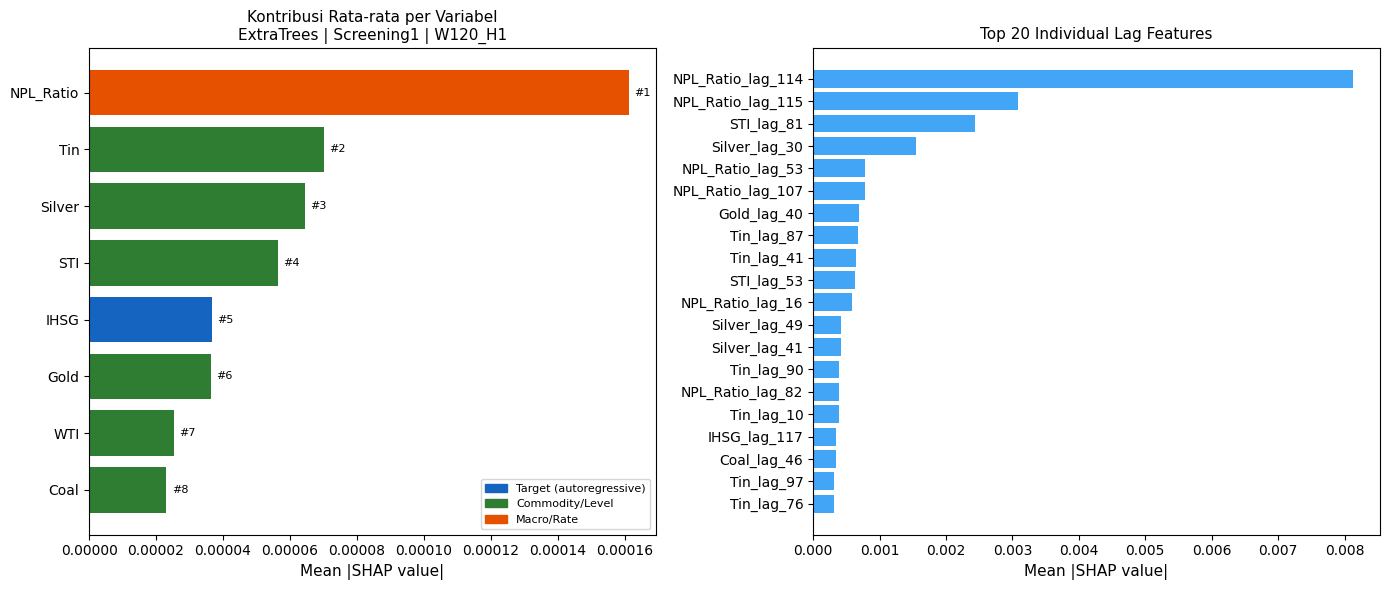

Saved: plot_shap_bar_ExtraTrees_120.png


In [8]:
CAT_COLOR = {
    "Target (autoregressive)": "#1565C0",
    "Commodity/Level":         "#2E7D32",
    "Macro/Rate":              "#E65100",
    "Regional":                "#6A1B9A",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Kiri: Variable-level importance ─────────────────────────────────────────
colors = [CAT_COLOR[c] for c in shap_df["Category"]]
bars = axes[0].barh(shap_df["Variable"][::-1], shap_df["Mean_Abs_SHAP"][::-1],
                    color=colors[::-1])
axes[0].set_xlabel("Mean |SHAP value|", fontsize=11)
axes[0].set_title(f"Kontribusi Rata-rata per Variabel\n{MODEL_NAME} | {COV_GROUP} | W{WINDOW}_H{HORIZON}",
                  fontsize=11)
for bar, (_, row) in zip(bars, shap_df[::-1].iterrows()):
    axes[0].text(bar.get_width() + shap_df["Mean_Abs_SHAP"].max()*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f"#{row['Rank']}", va="center", fontsize=8)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color=v, label=k) for k, v in CAT_COLOR.items() if k in shap_df["Category"].values]
axes[0].legend(handles=legend, fontsize=8, loc="lower right")

# ── Kanan: Top 20 individual lag features ────────────────────────────────────
lag_shap = (pd.DataFrame({"feature": feat_names,
                           "mean_abs": np.mean(np.abs(shap_arr), axis=0)})
            .sort_values("mean_abs", ascending=False).head(20))

axes[1].barh(lag_shap["feature"][::-1], lag_shap["mean_abs"][::-1], color="#42A5F5")
axes[1].set_xlabel("Mean |SHAP value|", fontsize=11)
axes[1].set_title("Top 20 Individual Lag Features", fontsize=11)

plt.tight_layout()
plt.savefig(f"plot_shap_bar_{MODEL_NAME}_{WINDOW}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: plot_shap_bar_{MODEL_NAME}_{WINDOW}.png")

### Plot 2 — Beeswarm: Arah & Magnitude Pengaruh per Observasi

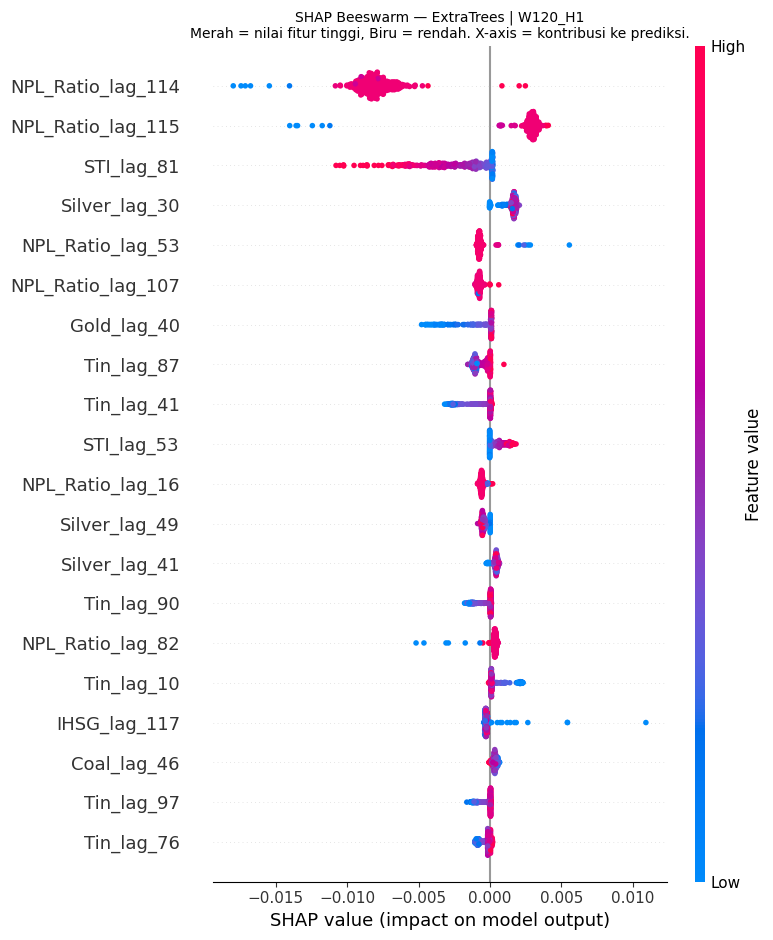

Saved: plot_shap_beeswarm_ExtraTrees_120.png


In [9]:
# Top features untuk beeswarm
top_n  = min(20, len(feat_names))
top_idx = lag_shap.index.tolist()[::-1]
feat_top = [feat_names[i] for i in top_idx]
X_top    = X_sample[:, top_idx]

plt.figure(figsize=(9, 8))
shap.summary_plot(shap_arr[:, top_idx], X_top,
                  feature_names=feat_top,
                  show=False, max_display=top_n, plot_type="dot")
plt.title(f"SHAP Beeswarm — {MODEL_NAME} | W{WINDOW}_H{HORIZON}\n"
          f"Merah = nilai fitur tinggi, Biru = rendah. X-axis = kontribusi ke prediksi.",
          fontsize=10)
plt.tight_layout()
plt.savefig(f"plot_shap_beeswarm_{MODEL_NAME}_{WINDOW}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: plot_shap_beeswarm_{MODEL_NAME}_{WINDOW}.png")

### Plot 3 — Dependence Plot: Hubungan Non-linear per Variabel Top

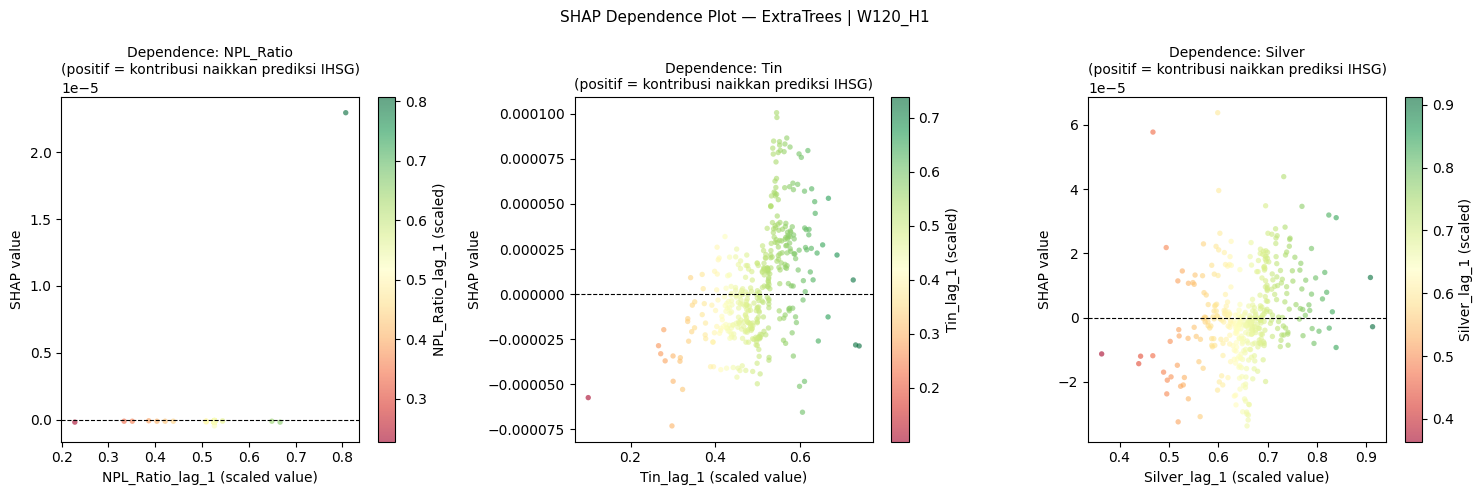

Saved: plot_shap_dependence_ExtraTrees_120.png


In [10]:
# Tampilkan dependence plot untuk 3 variabel dengan SHAP tertinggi
# (bukan IHSG autoregressive)
non_ihsg = shap_df[shap_df["Variable"] != "IHSG"]
top3_vars = non_ihsg["Variable"].head(3).tolist()

fig, axes = plt.subplots(1, len(top3_vars), figsize=(5*len(top3_vars), 5))
if len(top3_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, top3_vars):
    # Gunakan lag_1 sebagai representasi
    lag1_feat = f"{var}_lag_1"
    if lag1_feat not in feat_names:
        ax.set_title(f"{var} tidak ditemukan"); continue

    feat_idx  = feat_names.index(lag1_feat)
    x_vals    = X_sample[:, feat_idx]
    y_vals    = shap_arr[:, feat_idx]

    sc = ax.scatter(x_vals, y_vals, c=x_vals, cmap="RdYlGn",
                    alpha=0.6, s=15, linewidths=0)
    plt.colorbar(sc, ax=ax, label=f"{var}_lag_1 (scaled)")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"{var}_lag_1 (scaled value)", fontsize=10)
    ax.set_ylabel("SHAP value", fontsize=10)
    ax.set_title(f"Dependence: {var}\n(positif = kontribusi naikkan prediksi IHSG)", fontsize=10)

plt.suptitle(f"SHAP Dependence Plot — {MODEL_NAME} | W{WINDOW}_H{HORIZON}", fontsize=11)
plt.tight_layout()
plt.savefig(f"plot_shap_dependence_{MODEL_NAME}_{WINDOW}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: plot_shap_dependence_{MODEL_NAME}_{WINDOW}.png")

### Plot 4 — Waterfall: Dekomposisi Satu Prediksi Spesifik

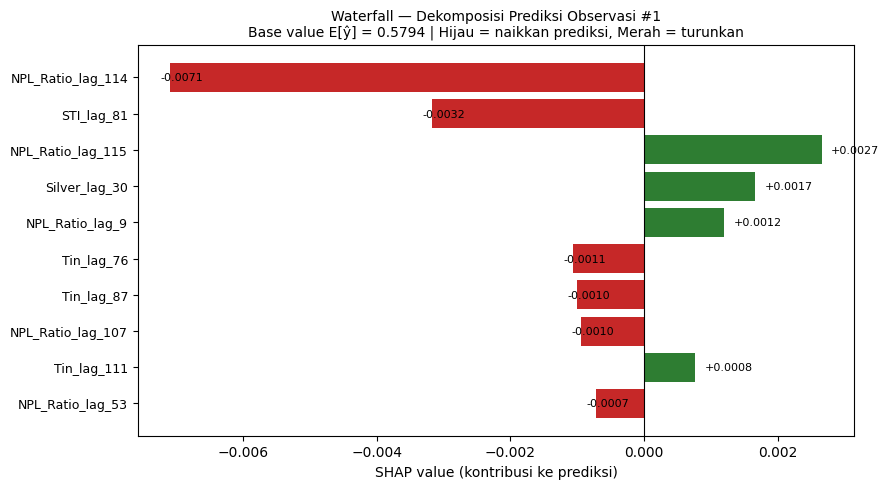

Saved: plot_shap_waterfall_ExtraTrees_obs0.png


In [11]:
# Pilih satu observasi untuk dijelaskan (default: observasi pertama test set)
obs_idx = 0

shap_vals_obs = shap_arr[obs_idx]
x_obs         = X_sample[obs_idx]
base_val      = (explainer.expected_value
                 if not hasattr(explainer.expected_value,'__len__')
                 else explainer.expected_value[0])

# Ambil top 10 fitur dengan |SHAP| terbesar untuk obs ini
abs_shap_obs = np.abs(shap_vals_obs)
top10_idx    = np.argsort(abs_shap_obs)[-10:][::-1]
top10_feats  = [feat_names[i] for i in top10_idx]
top10_shap   = shap_vals_obs[top10_idx]

fig, ax = plt.subplots(figsize=(9, 5))
colors_wf = ["#2e7d32" if v > 0 else "#c62828" for v in top10_shap]
bars = ax.barh(range(len(top10_feats)), top10_shap[::-1], color=colors_wf[::-1])
ax.set_yticks(range(len(top10_feats)))
ax.set_yticklabels(top10_feats[::-1], fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, top10_shap[::-1]):
    ax.text(bar.get_width() + (abs(top10_shap).max()*0.02) * np.sign(val),
            bar.get_y() + bar.get_height()/2,
            f"{val:+.4f}", va="center", fontsize=8)
ax.set_xlabel("SHAP value (kontribusi ke prediksi)", fontsize=10)
ax.set_title(f"Waterfall — Dekomposisi Prediksi Observasi #{obs_idx+1}\n"
             f"Base value E[ŷ] = {base_val:.4f} | Hijau = naikkan prediksi, Merah = turunkan",
             fontsize=10)
plt.tight_layout()
plt.savefig(f"plot_shap_waterfall_{MODEL_NAME}_obs{obs_idx}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: plot_shap_waterfall_{MODEL_NAME}_obs{obs_idx}.png")

## 7. Interpretasi Ekonomi

Panduan membaca hasil SHAP untuk penjelasan ke dosen ekonomi.

In [12]:
print("="*65)
print("  INTERPRETASI EKONOMI — SHAP Results")
print(f"  Model: {MODEL_NAME} | Group: {COV_GROUP} | W{WINDOW}_H{HORIZON}")
print("="*65)

print("\n1. RANKING PENGARUH VARIABEL (ekuivalen dengan |β| pada regresi):")
print("-"*55)
for _, row in shap_df.iterrows():
    bar = "█" * int(row["Mean_Abs_SHAP"] / shap_df["Mean_Abs_SHAP"].max() * 20)
    print(f"  #{int(row['Rank']):<2} {row['Variable']:<22} {bar}")

print(f"\n2. MAKNA EKONOMIS (lag = hari perdagangan sebelumnya):")
print("-"*55)
print(f"  • SHAP > 0 → variabel tersebut MENAIKKAN prediksi IHSG")
print(f"  • SHAP < 0 → variabel tersebut MENURUNKAN prediksi IHSG")
print(f"  • |SHAP|   → seberapa besar pengaruhnya")
print(f"  • Lag-1 dari {top3_vars[0] if top3_vars else 'variabel'} artinya:")
print(f"    'Nilai {top3_vars[0] if top3_vars else 'variabel'} kemarin mempengaruhi IHSG hari ini'")

print(f"\n3. PERBANDINGAN DENGAN REGRESI LINEAR:")
print("-"*55)
print(f"  Linear regression  → satu β per variabel (konstan)")
print(f"  SHAP               → distribusi φ per variabel (dinamis)")
print(f"  Mean SHAP          ≈ koefisien β rata-rata")
print(f"  Dependence plot    ≈ kurva pengaruh non-linear")

print(f"\n4. UNTUK DOSEN EKONOMI:")
print("-"*55)
top1 = shap_df.iloc[0]["Variable"]
top1_cat = shap_df.iloc[0]["Category"]
print(f"  'Dari model prediksi IHSG, variabel yang paling berpengaruh")
print(f"   adalah {top1} ({top1_cat}). Rata-rata, perubahan")
print(f"   {top1} kemarin memberikan kontribusi terbesar dalam")
print(f"   menentukan arah prediksi IHSG hari ini, melebihi")
for _, row in shap_df.iloc[1:3].iterrows():
    print(f"   {row['Variable']} ({row['Category']}) yang berada di posisi #{int(row['Rank'])}.'")
print()
print("  Hubungan ini tidak bersifat linear/konstan seperti regresi,")
print("  melainkan bervariasi tergantung kondisi pasar (lihat dependence plot).")

  INTERPRETASI EKONOMI — SHAP Results
  Model: ExtraTrees | Group: Screening1 | W120_H1

1. RANKING PENGARUH VARIABEL (ekuivalen dengan |β| pada regresi):
-------------------------------------------------------
  #1  NPL_Ratio              ████████████████████
  #2  Tin                    ████████
  #3  Silver                 ███████
  #4  STI                    ██████
  #5  IHSG                   ████
  #6  Gold                   ████
  #7  WTI                    ███
  #8  Coal                   ██

2. MAKNA EKONOMIS (lag = hari perdagangan sebelumnya):
-------------------------------------------------------
  • SHAP > 0 → variabel tersebut MENAIKKAN prediksi IHSG
  • SHAP < 0 → variabel tersebut MENURUNKAN prediksi IHSG
  • |SHAP|   → seberapa besar pengaruhnya
  • Lag-1 dari NPL_Ratio artinya:
    'Nilai NPL_Ratio kemarin mempengaruhi IHSG hari ini'

3. PERBANDINGAN DENGAN REGRESI LINEAR:
-------------------------------------------------------
  Linear regression  → satu β per varia